=== Classification Report ===
              precision    recall  f1-score   support

     12352.0       0.00      0.00      0.00         0
     12354.0       0.00      0.00      0.00         1
     12358.0       0.00      0.00      0.00         1
     12370.0       0.00      0.00      0.00         1
     12371.0       0.00      0.00      0.00         1
     12372.0       0.00      0.00      0.00         2
     12374.0       0.00      0.00      0.00         1
     12388.0       0.00      0.00      0.00         1
     12399.0       0.00      0.00      0.00         1
     12405.0       0.00      0.00      0.00         2
     12409.0       0.00      0.00      0.00         1
     12415.0       0.00      0.00      0.00         3
     12417.0       0.00      0.00      0.00         1
     12429.0       0.00      0.00      0.00         2
     12431.0       0.00      0.00      0.00         2
     12433.0       0.00      0.00      0.00         1
     12449.0       0.00      0.00      0.00        

H:\Data Minning\BTL2\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
H:\Data Minning\BTL2\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
H:\Data Minning\BTL2\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
H:\Data Minning\BTL2\venv\Lib\sit

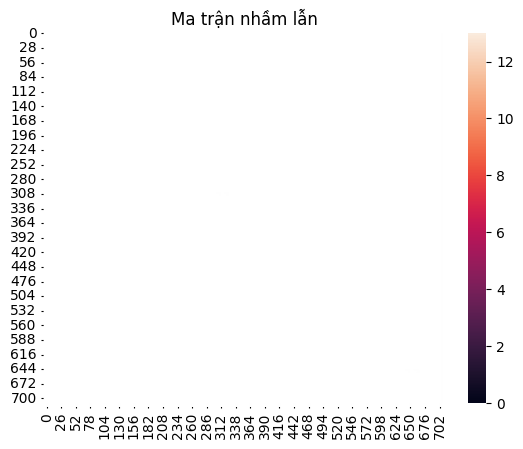

,Feature,Importance
1,UnitPrice,0.506852
0,Quantity,0.493148


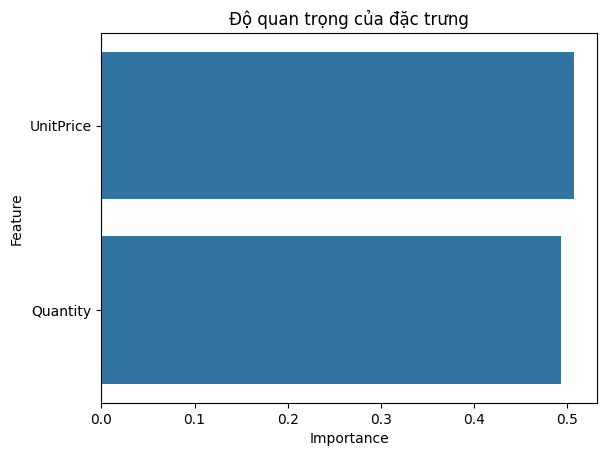

In [1]:
# =====================
# 1. IMPORT THƯ VIỆN
# =====================
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# =====================
# 2. ĐỌC DỮ LIỆU
# =====================
df = pd.read_csv("../outputs/cleaned_data.csv")

# 🔥 GIẢM DỮ LIỆU (TRÁNH LỖI RAM)
if len(df) > 5000:
    df = df.sample(n=5000, random_state=42)

# =====================
# 3. CHỌN CỘT SỐ
# =====================
df = df.select_dtypes(include=['int64','float64'])

# Nếu quá nhiều cột → giảm xuống
if df.shape[1] > 10:
    df = df.iloc[:, :10]

# =====================
# 4. TÁCH X, y
# =====================
X = df.drop(df.columns[-1], axis=1)
y = df[df.columns[-1]]

# =====================
# 5. CHIA TRAIN/TEST
# =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================
# 6. HUẤN LUYỆN MODEL (NHẸ)
# =====================
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# =====================
# 7. DỰ ĐOÁN
# =====================
y_pred = model.predict(X_test)

# Với ROC cần xác suất
if len(set(y)) == 2:
    y_prob = model.predict_proba(X_test)[:,1]

# =====================
# 8. ĐÁNH GIÁ
# =====================
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

# =====================
# 9. CONFUSION MATRIX
# =====================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Ma trận nhầm lẫn")
plt.savefig("../outputs/confusion_matrix.png")
plt.show()

# =====================
# 10. ROC CURVE (NẾU BINARY)
# =====================
if len(set(y)) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title("Đường cong ROC")
    plt.savefig("../outputs/roc_curve.png")
    plt.show()

# =====================
# 11. FEATURE IMPORTANCE
# =====================
importances = model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

display(feat_df)

plt.figure()
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Độ quan trọng của đặc trưng")
plt.savefig("../outputs/feature_importance.png")
plt.show()